In [7]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.lines import Line2D
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [5]:
df_avg = pd.read_csv("carnitines_with_putative_explanation_only_CHO_wo_oxygen.tsv", sep="\t")

In [6]:
df_avg.head()

,putative explanation,delta_mass_r2,precmz,mass_defect,counts
0,CAR C10:0,154.135,316.247375,0.000427,12394
1,CAR C10:0;O,170.130,332.239990,0.000391,5083
2,CAR C10:0;O2,186.125,348.237625,0.000359,366
3,CAR C10:0;O4,218.110,380.227330,0.000289,2
4,CAR C10:1,152.120,314.232640,0.000382,19576


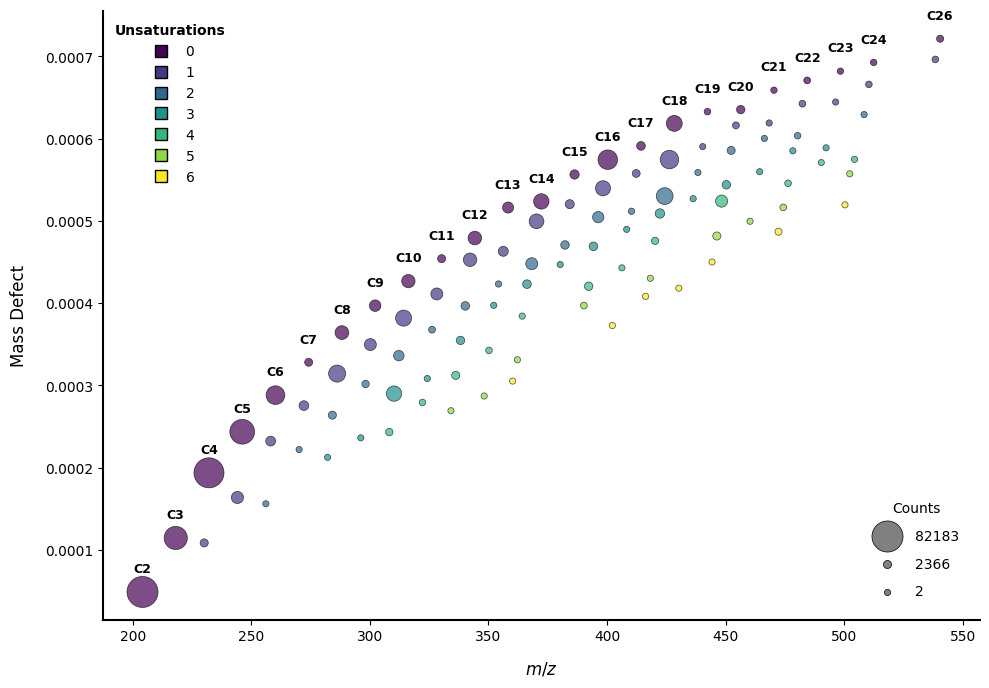

In [9]:
# --- 1) Filter only explanations without oxygen ---
df_filtered = df_avg.loc[~df_avg['putative explanation'].str.contains('O', na=False)].copy()

# --- 2) Extract #C and #unsaturations ---
def extract_carbon_unsaturation(explanation):
    m = re.search(r'CAR C(\d+):(\d+)', str(explanation))
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

df_filtered['carbons'], df_filtered['unsaturations'] = zip(
    *df_filtered['putative explanation'].apply(extract_carbon_unsaturation)
)

# --- 3) Scale 'counts' (kept as in your code) ---
min_counts = df_filtered['counts'].min()
max_counts = df_filtered['counts'].max()
min_size, max_size = 20, 500
df_filtered['scaled_counts'] = min_size + (df_filtered['counts'] - min_counts) * (max_size - min_size) / (max_counts - min_counts)

# --- 4) Colors by unsaturation ---
unique_unsaturations = sorted(df_filtered['unsaturations'].dropna().unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_unsaturations)))
color_map = dict(zip(unique_unsaturations, colors))

# --- 5) Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter (unchanged: circles with variable sizes)
for unsaturation, group in df_filtered.groupby('unsaturations'):
    ax.scatter(
        group['precmz'],
        group['mass_defect'],
        s=group['scaled_counts'],
        c=[color_map.get(unsaturation, 'gray')],
        label=f'{unsaturation}',
        alpha=0.7,
        edgecolors='k',
        linewidth=0.5
        # default marker (circle)
    )
    if unsaturation == 0:
        for _, row in group.iterrows():
            if pd.notna(row['carbons']):
                ax.text(
                    row['precmz'], row['mass_defect'] + 0.00002,
                    f"C{int(row['carbons'])}",
                    ha='center', va='bottom',
                    fontsize=9, weight='bold', color='black'
                )

# --- 6) Style ---
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.set_xlabel('$m/z$', style='italic', fontsize=12, labelpad=12)
ax.set_ylabel('Mass Defect', fontsize=12, labelpad=12)

# --- 7) Legend "Unsaturations" with square markers (proxies) ---
unsat_handles = [
    Line2D([0], [0], marker='s', linestyle='None',
           markerfacecolor=color_map[u], markeredgecolor='k',
           markersize=8, label=str(int(u)) if pd.notna(u) else 'NA')
    for u in unique_unsaturations
]
leg1 = ax.legend(handles=unsat_handles, title='Unsaturations', loc='upper left', frameon=False)
leg1.set_title("Unsaturations", prop={'weight': 'bold'})

# --- 8) Legend "Counts" (kept as in your code) ---
sizes = df_filtered['counts'].drop_duplicates().sort_values(ascending=False)
if len(sizes) > 3:
    sizes = sizes.iloc[[0, len(sizes)//2, -1]]
elif len(sizes) < 3:
    sizes = sizes.iloc[0:len(sizes)]

scaled_sizes = min_size + (sizes - min_counts) * (max_size - min_size) / (max_counts - min_counts)
legend_markers = [
    plt.scatter([], [], s=s, color='gray', edgecolors='k', linewidth=0.5, label=str(int(size)))
    for s, size in zip(scaled_sizes, sizes)
]
leg2 = ax.legend(handles=legend_markers, title='Counts', loc='lower right', frameon=False,
                 labelspacing=1, borderpad=1, handletextpad=1)
ax.add_artist(leg1)

plt.tight_layout()
# plt.savefig("mass_defect_plot_CHO_without_oxygen.png", dpi=600, bbox_inches='tight')
plt.savefig('mass_defect_onlyCHO_withoutO.pdf')
plt.show()
